# Ultimate Technologies Data Analysis Challenge

This notebook contains solutions for the Ultimate Technologies take-home challenge, including:

1. Exploratory data analysis of user login activity
2. Experiment and metrics design
3. Predictive modeling for rider retention

The analysis uses Python, pandas, matplotlib, and scikit-learn to explore user behavior patterns and build predictive insights related to rider retention.

## Part 1 — Exploratory Data Analysis

The `logins.json` dataset contains timestamps of user login events in a geographic region. 

The objective of this analysis is to:
- Aggregate login counts into 15-minute intervals
- Visualize login activity over time
- Identify daily and weekly demand patterns
- Report any notable data quality issues

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Load Login Data

In [2]:
logins = pd.read_json("logins.json")

logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


### Initial Data Inspection

In [3]:
logins.info()

print("\nMissing Values:")
print(logins.isna().sum())

print("\nDuplicate Rows:")
print(logins.duplicated().sum())

logins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB

Missing Values:
login_time    0
dtype: int64

Duplicate Rows:
877


,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


### Convert Login Time to Datetime Format

In [4]:
logins["login_time"] = pd.to_datetime(logins["login_time"])

logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


### Set Login Time as Index

In [5]:
logins = logins.set_index("login_time")

logins.head()

""
login_time
1970-01-01 20:13:18
1970-01-01 20:16:10
1970-01-01 20:16:37
1970-01-01 20:16:36
1970-01-01 20:26:21


### Aggregate Login Counts into 15-Minute Intervals

In [6]:
login_counts = logins.resample("15min").size()

login_counts.head()

login_time
1970-01-01 20:00:00    2
1970-01-01 20:15:00    6
1970-01-01 20:30:00    9
1970-01-01 20:45:00    7
1970-01-01 21:00:00    1
Freq: 15min, dtype: int64

### Login Activity Over Time

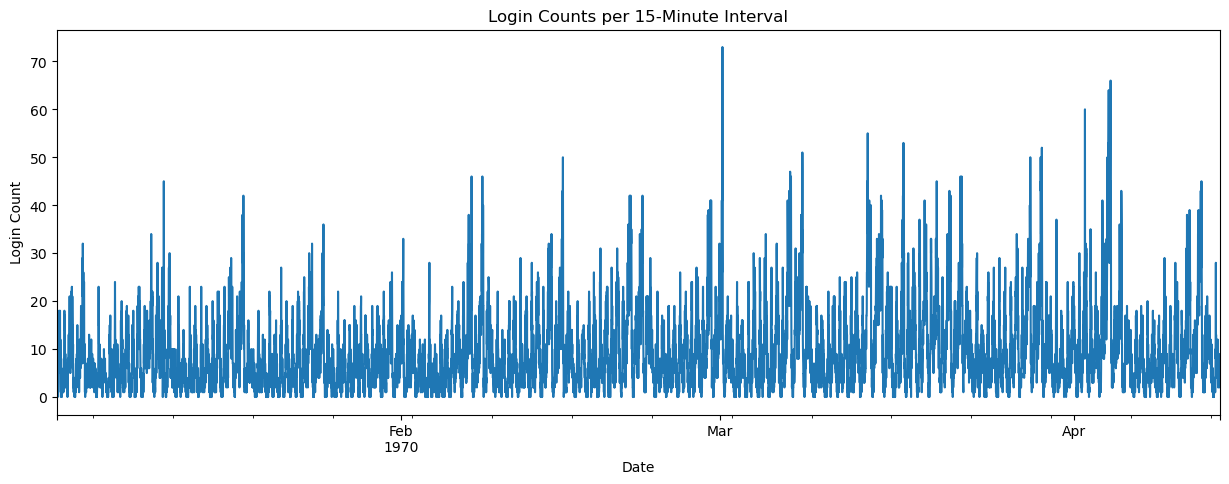

In [7]:
plt.figure(figsize=(15,5))

login_counts.plot()

plt.title("Login Counts per 15-Minute Interval")
plt.xlabel("Date")
plt.ylabel("Login Count")

plt.show()

### Average Login Activity by Hour of Day

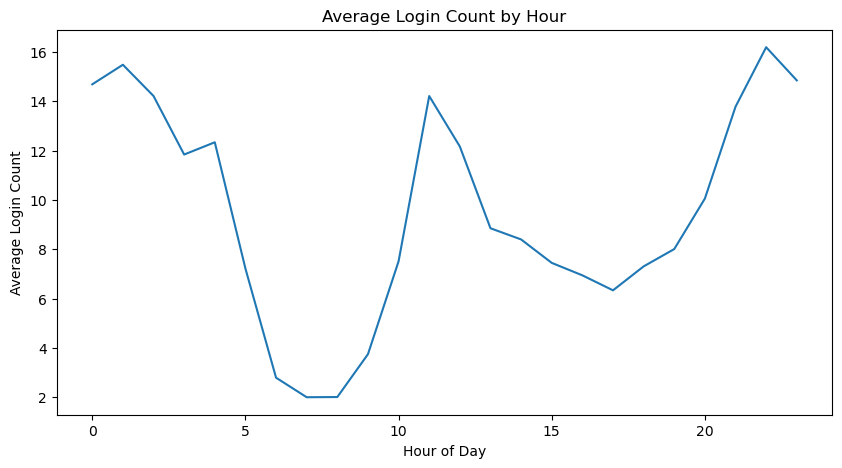

In [8]:
hourly_avg = login_counts.groupby(login_counts.index.hour).mean()

plt.figure(figsize=(10,5))

hourly_avg.plot()

plt.title("Average Login Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Login Count")

plt.show()

### Average Login Activity by Day of Week

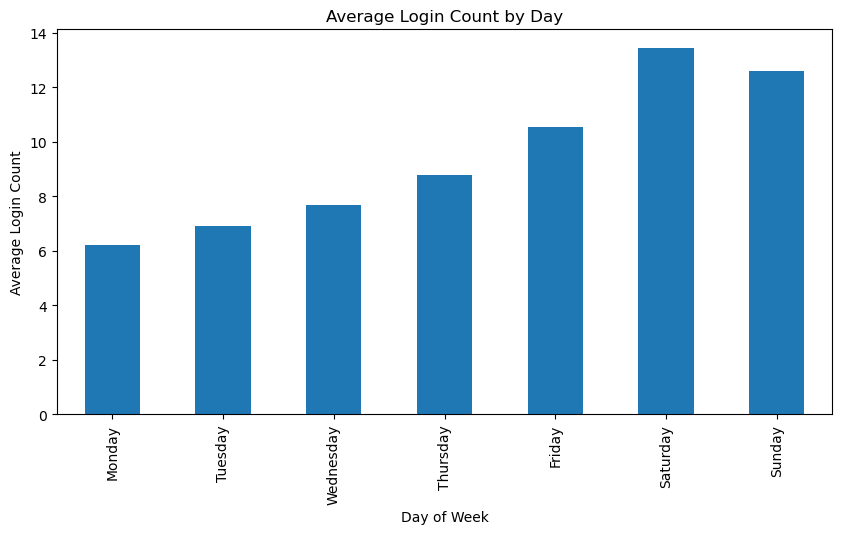

In [9]:
daily_avg = login_counts.groupby(login_counts.index.day_name()).mean()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_avg = daily_avg.reindex(day_order)

plt.figure(figsize=(10,5))

daily_avg.plot(kind="bar")

plt.title("Average Login Count by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Login Count")

plt.show()

### Key Observations

- Login demand shows clear cyclical patterns over time, with repeated spikes across the full time series.
- Average login activity is lowest in the early morning, especially around 6 AM to 8 AM.
- Demand increases sharply late in the morning and reaches another strong peak late at night.
- The highest average hourly activity appears around late evening to shortly after midnight.
- Weekend demand is noticeably higher than weekday demand, with Saturday showing the highest average login activity.
- Average login activity gradually increases from Monday through Saturday, then remains elevated on Sunday.
- No missing values were identified in the login timestamp data, and the data appears suitable for time-based aggregation.

## Part 2 — Experiment and Metrics Design

This section proposes an experiment to determine whether reimbursing toll costs would encourage driver partners to operate in both Gotham and Metropolis instead of remaining exclusive to one city.

### Key Measure of Success

The key measure of success would be the percentage of drivers who complete trips in both Gotham and Metropolis during the experiment period.

This metric directly measures whether toll reimbursement encourages drivers to serve both cities, rather than only measuring indirect outcomes such as total trip volume or revenue.

### Experimental Design

To evaluate the effectiveness of toll reimbursement, drivers could be randomly assigned into two groups:

- Control group: drivers continue operating under the current system without toll reimbursement
- Treatment group: drivers receive full reimbursement for toll expenses

The experiment would run over several weeks in order to capture both weekday and weekend demand patterns.

The primary outcome measured would be the percentage of drivers actively completing trips in both cities during the observation period.

### Statistical Testing

A statistical test would be used to determine whether the difference between the treatment and control groups is statistically significant rather than due to random variation.

A two-proportion z-test or chi-square test could be used to compare the percentage of drivers operating in both cities between the two groups.

Additional analyses such as t-tests or regression analysis could also be used to compare supporting metrics including:
- total trips completed
- driver utilization
- rider wait times
- average driver earnings

### Interpretation and Recommendations

If the treatment group demonstrates a statistically significant increase in cross-city participation, Ultimate could consider expanding the toll reimbursement program across both cities.

Potential benefits of the program may include:
- improved driver availability
- reduced rider wait times
- increased trip completion rates
- better coverage during high-demand periods

However, the operational cost of reimbursing tolls should also be compared against any increase in revenue or platform utilization.

Potential limitations of the experiment include:
- seasonal demand fluctuations
- driver behavior changes over time
- uneven participation between weekdays and weekends
- external factors that may influence rider demand

## Part 3 — Predictive Modeling

This section explores rider retention using the provided Ultimate user dataset. 

The objective is to identify factors associated with long-term rider retention and build a predictive model to estimate whether a user will remain active during their sixth month on the platform.

### Load Retention Dataset

In [10]:
df = pd.read_json("ultimate_data_challenge.json")

df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


### Initial Data Inspection

In [11]:
df.info()

print("\nMissing Values:")
print(df.isna().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB

Missing Values:
city                         0
trips_in_first_30_days       0

### Data Cleaning and Preprocessing

In [12]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_trip_date"] = pd.to_datetime(df["last_trip_date"])

In [13]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64


In [14]:
df["avg_rating_by_driver"] = df["avg_rating_by_driver"].fillna(
    df["avg_rating_by_driver"].median()
)

df["avg_rating_of_driver"] = df["avg_rating_of_driver"].fillna(
    df["avg_rating_of_driver"].median()
)

df["phone"] = df["phone"].fillna("Unknown")

In [15]:
print("\nMissing Values After Cleaning:")
print(df.isna().sum())


Missing Values After Cleaning:
city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
dtype: int64


### Define Rider Retention

Users are considered retained if they completed a trip within the 30 days preceding the most recent trip date in the dataset.

In [16]:
cutoff_date = df["last_trip_date"].max() - pd.Timedelta(days=30)

df["retained"] = df["last_trip_date"] >= cutoff_date

In [17]:
retained_fraction = df["retained"].mean()

print("Retention Rate:", retained_fraction)
print("Retention Percentage:", retained_fraction * 100)

Retention Rate: 0.37608
Retention Percentage: 37.608000000000004


### Feature Preparation

In [18]:
X = df.drop(columns=["retained", "last_trip_date", "signup_date"])

y = df["retained"]

In [19]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,city_King's Landing,city_Winterfell,phone_Unknown,phone_iPhone
0,4,4.7,1.10,15.4,True,46.2,3.67,5.0,True,False,False,True
1,0,5.0,1.00,0.0,False,50.0,8.26,5.0,False,False,False,False
2,3,4.3,1.00,0.0,False,100.0,0.77,5.0,False,False,False,True
3,9,4.6,1.14,20.0,True,80.0,2.36,4.9,True,False,False,True
4,14,4.4,1.19,11.8,False,82.4,3.13,4.9,False,True,False,False


In [20]:
X.shape

(50000, 12)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

### Logistic Regression Model

In [22]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = log_reg.predict(X_test)

### Model Evaluation

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7198

Classification Report:
              precision    recall  f1-score   support

       False       0.74      0.86      0.79      6239
        True       0.68      0.49      0.57      3761

    accuracy                           0.72     10000
   macro avg       0.71      0.67      0.68     10000
weighted avg       0.71      0.72      0.71     10000


Confusion Matrix:
[[5370  869]
 [1933 1828]]


In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
8,city_King's Landing,1.701943
11,phone_iPhone,1.094456
4,ultimate_black_user,0.878078
9,city_Winterfell,0.485393
10,phone_Unknown,0.448134
0,trips_in_first_30_days,0.117256
3,surge_pct,0.004882
5,weekday_pct,-0.000095
6,avg_dist,-0.036278
1,avg_rating_of_driver,-0.128383


In [26]:
coefficients.tail(10)

,Feature,Coefficient
4,ultimate_black_user,0.878078
9,city_Winterfell,0.485393
10,phone_Unknown,0.448134
0,trips_in_first_30_days,0.117256
3,surge_pct,0.004882
5,weekday_pct,-0.000095
6,avg_dist,-0.036278
1,avg_rating_of_driver,-0.128383
7,avg_rating_by_driver,-0.158262
2,avg_surge,-0.258220


### Model Interpretation

The logistic regression model identified several features associated with rider retention.

Users with higher activity during their first 30 days, premium service usage, and certain device or city characteristics appeared more likely to remain retained.

Features with positive coefficients increased the predicted likelihood of retention, while negative coefficients were associated with reduced retention likelihood.

The results suggest that early engagement behavior may play an important role in long-term platform activity.

### Business Recommendations

The model results suggest that early rider engagement plays an important role in long-term retention.

Users who completed more trips during their first 30 days and those who used premium services such as Ultimate Black appeared more likely to remain active over time.

Ultimate could potentially improve retention by:
- encouraging higher trip frequency among new users
- offering targeted promotions during the first month after signup
- incentivizing premium service usage
- identifying low-engagement users early for retention campaigns

Additionally, rider experience metrics such as ratings may help identify users at risk of churn.

### Final Conclusion

This analysis explored user login activity, experimental design considerations, and rider retention modeling for Ultimate Technologies.

The exploratory analysis identified clear cyclical demand patterns in login activity, while the experimental design proposed a framework for evaluating toll reimbursement incentives across cities.

The predictive modeling analysis demonstrated that early user engagement and platform usage behaviors were associated with rider retention. These insights may help Ultimate improve long-term user engagement through targeted retention strategies.